In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "/kaggle/input/datasets/hoorawan/titaniccc/titanic.csv"
)

In [3]:
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]
df['Age'].fillna(df['Age'].median(), inplace = True)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

X = df.drop('Survived', axis = 1)
y = df['Survived']

/tmp/ipykernel_55/2340485995.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace = True)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size = 0.2, random_state = 42
)

In [6]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors= 5),
    "Decision Tree": DecisionTreeClassifier(max_depth = 5),
    "Random Forest": RandomForestClassifier(n_estimators = 100)
}

In [7]:
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"{name} Accuracy: ", accuracy_score(y_test, preds))

KNN Accuracy:  0.6759776536312849
Decision Tree Accuracy:  0.8044692737430168
Random Forest Accuracy:  0.7988826815642458


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors = 5)
knn_scaled.fit(X_train_scaled, y_train)
preds_knn_scaled = knn_scaled.predict(X_test_scaled)
acc_knn_scaled = accuracy_score(y_test, preds_knn_scaled)

print("with scaling KNN", acc_knn_scaled)

with scaling KNN 0.8212290502793296


In [11]:



from sklearn.model_selection import GridSearchCV


In [12]:
param_grid = {
   'n_estimators' : [50, 100],
    'max_depth' :  [None, 5, 10],
    'min_samples_split' : [2, 5]
}
# 12 combinations  - out of 12 , 1 will be selected - best settings 
# 12 models
rf = RandomForestClassifier(random_state = 42)




In [13]:
grid = GridSearchCV(
    rf,
    param_grid,
    cv = 5,
    scoring = "accuracy"
)


In [14]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 5, 10],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100]},
             scoring='accuracy')

In [15]:
print("Best Parameters: ", grid.best_params_)
print("Best Accuracy: ", grid.best_score_)

Best Parameters:  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
Best Accuracy:  0.8384713877671623


In [16]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters = 5, random_state = 42)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters
df.head()



,Survived,Pclass,Sex,Age,Fare,Cluster
0,0,3,0,22.0,7.2500,0
1,1,1,1,38.0,71.2833,4
2,1,3,1,26.0,7.9250,2
3,1,1,1,35.0,53.1000,4
4,0,3,0,35.0,8.0500,0


In [18]:
# within-cluster sum of squares


wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters = k, random_state = 42 )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    


In [19]:
import matplotlib.pyplot as plt

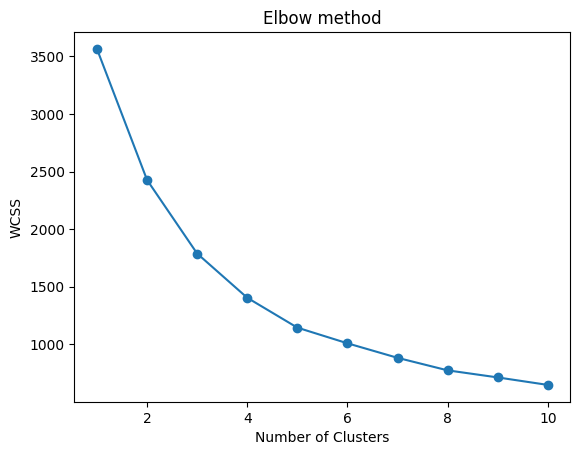

In [20]:
plt.plot(range(1,11), wcss, marker = 'o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow method")
plt.show()

In [21]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, clusters)
print("Silhouette score: ", score)

Silhouette score:  0.46007751704049027


In [22]:
for k in range( 2, 8):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k = {k}, Score: {score}")

k = 2, Score: 0.39768335551801015
k = 3, Score: 0.42286134464621117
k = 4, Score: 0.44282404598649616
k = 5, Score: 0.46007751704049027
k = 6, Score: 0.4275635621859003
k = 7, Score: 0.4512670477447412


In [28]:
from sklearn.decomposition import PCA

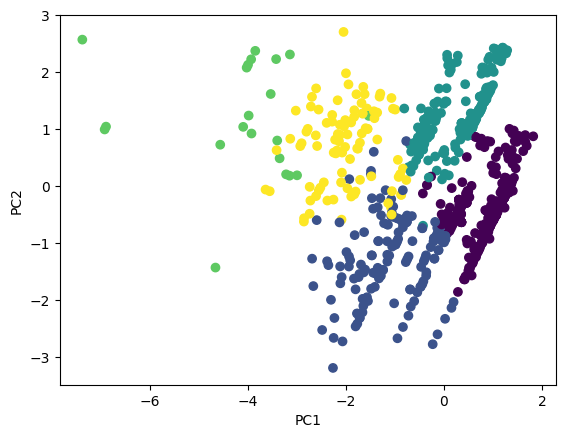

In [29]:


pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c= clusters)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [ ]:
Model Saving - 




job.dump{} - convert trained model into a file

.pkl - pickle file ( binary format)

serialization - converting python object -> file





In [31]:
import joblib

best_model = grid.best_estimator_

joblib.dump(best_model, "titanic_rf_model.pk1")

['titanic_rf_model.pk1']

In [32]:
joblib.dump(scaler, "scaler.pk1")


['scaler.pk1']

In [34]:
model = joblib.load("titanic_rf_model.pk1")
scaler = joblib.load("scaler.pk1")

In [ ]:
import streamlit as st
import joblib 
import numpy as np



# Load the trained model
model = joblib.load("titanic_rf_model.pk1")

st.title("Titanic Survival Predictor")

# Input fields for user to enter passenger details

age = st.number_input("Age", 0,100,25)
fare = st.number_input("Fare", 0.0, 500.0, 50.0)
sex = st.selectbox("Sex", ["male", "female"])
pclass = st.radio("Passenger Class", [1,2,3])

sex_encoded = 0 if sex =="male" else 1

input_data = np.array([[pclass, sex_encoded, age, fare]])

if st.button("Predict Survival"):
    prediction = model.predict(input_data)
    probability = model.predict_proba(input_data)[0][1]

    if prediction[0] == 1:
        st.success(f"Passenger will survive")
    else:
        st.error(f"Passenger will not survive")

    st.subheader("Suvival Probability")
    st.write(f"{probability:.2%}")

In [39]:
# Pipelining: 

import pandas as pd

import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier




In [ ]:
df = pd.read_csv(
    "/kaggle/input/datasets/hoorawan/titaniccc/titanic.csv"
)

In [ ]:
y = df["Survived"]

X = df[["Pclass" , "Sex", "Age", "Fare", "Embarked"]]



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size = 0.2, random_state = 42
)

In [43]:
numeric_features = ['Age', 'Fare', 'Pclass']
categorical_features = ["Sex", "Embarked"]

In [49]:
numeric_transformer = Pipeline([
    ("impute", SimpleImputer(strategy = "mean")),
    ("scaler", StandardScaler())
])

In [55]:
categorical_transformer = Pipeline([
    ("impute", SimpleImputer(strategy = "most_frequent")),
    ('encoder', OneHotEncoder())
])

In [56]:
preprocessor = ColumnTransformers(
[
   ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])




NameError: name 'ColumnTransformers' is not defined